## Linear Regression

In [1]:
import pandas as pd
df = pd.read_csv('data/Salary_Data.csv')

In [3]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
df.sample(3)

,YearsExperience,Salary
24,8.7,109431.0
0,1.1,39343.0
29,10.5,121872.0


In [5]:
df.shape


(30, 2)

In [6]:
df.shape[1]

2

In [7]:
df.shape[0]

30

In [8]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [10]:
df.describe()        #only show numeric value columns
#df.describe(include='object')

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [11]:
X = df.drop(columns=['Salary'])
y = df['Salary']

In [12]:
X

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [13]:
X,y

(    YearsExperience
 0               1.1
 1               1.3
 2               1.5
 3               2.0
 4               2.2
 5               2.9
 6               3.0
 7               3.2
 8               3.2
 9               3.7
 10              3.9
 11              4.0
 12              4.0
 13              4.1
 14              4.5
 15              4.9
 16              5.1
 17              5.3
 18              5.9
 19              6.0
 20              6.8
 21              7.1
 22              7.9
 23              8.2
 24              8.7
 25              9.0
 26              9.5
 27              9.6
 28             10.3
 29             10.5,
 0      39343.0
 1      46205.0
 2      37731.0
 3      43525.0
 4      39891.0
 5      56642.0
 6      60150.0
 7      54445.0
 8      64445.0
 9      57189.0
 10     63218.0
 11     55794.0
 12     56957.0
 13     57081.0
 14     61111.0
 15     67938.0
 16     66029.0
 17     83088.0
 18     81363.0
 19     93940.0
 20     91738.0
 21     9827

In [14]:
from sklearn.model_selection import train_test_split
train_test_split(X,y,test_size =0.2)    #train_test = 0.8

[    YearsExperience
 13              4.1
 18              5.9
 20              6.8
 2               1.5
 16              5.1
 15              4.9
 21              7.1
 14              4.5
 10              3.9
 19              6.0
 25              9.0
 3               2.0
 27              9.6
 1               1.3
 9               3.7
 22              7.9
 8               3.2
 12              4.0
 7               3.2
 6               3.0
 29             10.5
 23              8.2
 24              8.7
 26              9.5,
     YearsExperience
 4               2.2
 0               1.1
 17              5.3
 5               2.9
 11              4.0
 28             10.3,
 13     57081.0
 18     81363.0
 20     91738.0
 2      37731.0
 16     66029.0
 15     67938.0
 21     98273.0
 14     61111.0
 10     63218.0
 19     93940.0
 25    105582.0
 3      43525.0
 27    112635.0
 1      46205.0
 9      57189.0
 22    101302.0
 8      64445.0
 12     56957.0
 7      54445.0
 6      60150.0
 29   

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2,random_state=0)

In [17]:
from sklearn.linear_model import LinearRegression


In [18]:
model = LinearRegression()

In [19]:
model

LinearRegression()

In [25]:
#Training Data
model.fit(X_train,y_train)

LinearRegression()

In [28]:
y_test

2      37731.0
28    122391.0
13     57081.0
10     63218.0
26    116969.0
24    109431.0
Name: Salary, dtype: float64

In [46]:
y_pred = model.predict(X_test)
y_pred

array([ 40748.96184072, 122699.62295594,  64961.65717022,  63099.14214487,
       115249.56285456, 107799.50275317])

In [34]:
pd.DataFrame({'y_test': y_test, 'y_pred': y_pred, 'MAE': y_test-y_pred})

,y_test,y_pred,MAE
2,37731.0,40748.961841,-3017.961841
28,122391.0,122699.622956,-308.622956
13,57081.0,64961.657170,-7880.657170
10,63218.0,63099.142145,118.857855
26,116969.0,115249.562855,1719.437145
24,109431.0,107799.502753,1631.497247


In [47]:
#Import metrics
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
print('Mean Absolute Error', mean_absolute_error(y_test,y_predict))
print('Mean Square Error', mean_squared_error(y_test,y_predict))
print('Root Mean Square Error', np.sqrt(mean_squared_error(y_test,y_predict)))  #should be more towards smaller value 
print('R2 Score', r2_score(y_test,y_predict)) #ans should be close to 1 for good accuracy

Mean Absolute Error 2446.1723690465064
Mean Square Error 12823412.298126562
Root Mean Square Error 3580.979237321345
R2 Score 0.988169515729126


In [48]:
#coefficeint = value of m
model.coef_

array([9312.57512673])

In [49]:
#Intercept value which is c
model.intercept_

np.float64(26780.099150628186)

In [50]:
y = (9312.57512673)*(1.5) + 26780.099150628186

In [51]:
y

40748.96184072319

In [43]:
model.predict([[1]])

C:\Users\Aqsa Mansoor\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36092.67427736])

In [52]:
import matplotlib.pyplot as plt 
import seaborn as sns

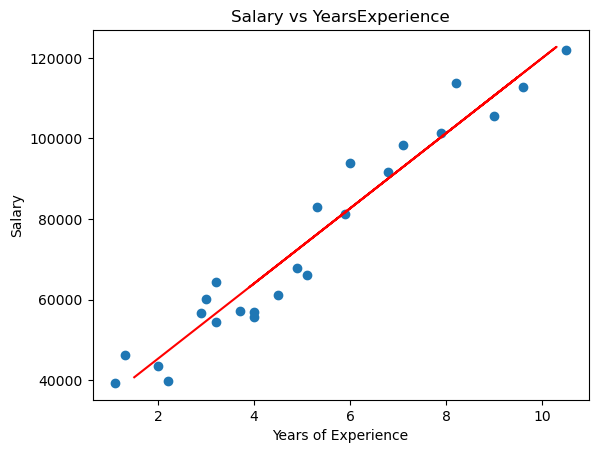

In [54]:
plt.scatter(X_train, y_train)
plt.plot(X_test,y_pred, color = 'r')
plt.title("Salary vs YearsExperience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()